In [3]:
import duckdb 
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from helper_functions.chart_utils import show_plot

# Electric Vehicle Insights and Visualizations

## Introduction of Analysis and Business Context

## Objectives / Questions
1) Which fifteen states have the most EV registrations? (ArcGIS)
1a) To further this exploration, which states prefer PHEVs versus BEVs in the United States?
2) Which ten counties and cities have the highest amount of EVs, split by PHEVs and BEVs? 
3) How does the count of EVs change over time in the top 10 counties?
4) What are the top ten most popular brands of cars?
5) What are the top ten most popular EV brands, model and model year?
6) How have the number of PHEVs and BEVs changed over the years?
7) How does Minimum and Maximum Electric Ranges change depending on brands?
8) How have Electric Ranges changed over the years?
DONE DONE DONE

Dealership Analysis
These questions look at the most popular counties and cities in Washington State, as we saw that the demand for EVs in Washington State was highest.

Which counties represent the strongest EV demand hotspots for dealership placement?
Which regions show a stronger preference for BEVs vs PHEVs, and how should that influence dealership inventory strategy?
Which non-Tesla manufacturers dominate EV demand in high-adoption regions?
Which EV models should dealerships prioritize based on regional demand patterns?
How does electric range vary across EV types and manufacturers, and what does that imply for dealership positioning?
How has electric range improved across model years, and what does this suggest about evolving consumer expectations?

## Loading Data

In [4]:
df = pd.read_csv("../data/cleaned/data_wo_fuel.csv")

## Creating a DataFrame with Non-Null Electric Ranges

In [5]:
# We can define a new dataframe using the following for calculations that involve electric range:
df_elec = df[df['Electric Range (in Miles)'].notnull()]

## Answering Questions: Querying and Visual Analysis

### Geographic Analysis (State → County → City)

#### Which fifteen states have the most EV registrations?

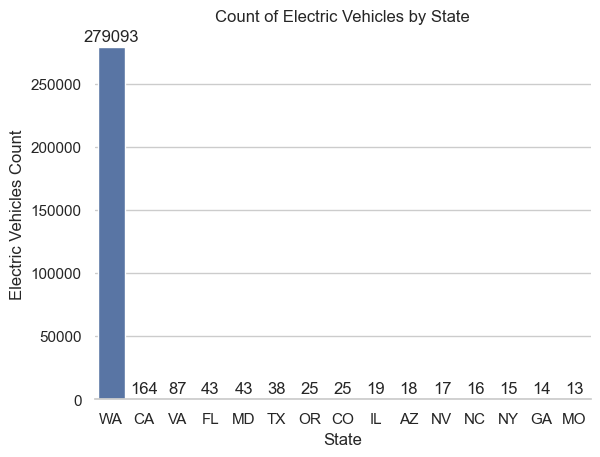

In [6]:
top_fifteen_states = duckdb.sql("""
                                SELECT State, COUNT(*) AS Count from df
                                GROUP BY State
                                ORDER BY Count DESC
                                LIMIT 15
                                """).df()
state_list = top_fifteen_states['State'].to_list()
show_plot(False, False, top_fifteen_states, 'State', 'Count', 'Count of Electric Vehicles by State', y_axis = 'Electric Vehicles Count', despine = 'left', plot_type='bar')

**Analysis**

Washington seems to have the most Electric Vehicle registrations by a huge margin, which indicates that this dataset has significantly more data to explore relevant to EVs in Washington.

We can investigate the distribution of EVs in the other 14 states by using a seperate bar chart. The results from the bar chart above indicates that our analysis by the end of this file may inadvertantly skew towards EVs in Washington. We can drill down on the counties within Washington to see which counties and cities are best for Electric Vehicle dealership presence.

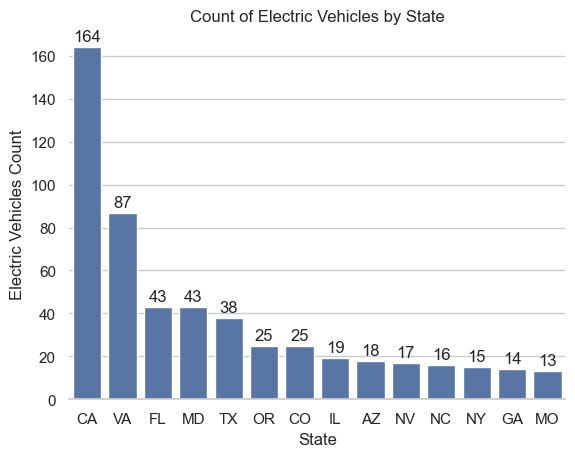

In [7]:
show_plot(False, False, top_fifteen_states[1:], 'State', 'Count', 'Count of Electric Vehicles by State', y_axis = 'Electric Vehicles Count', despine="left", plot_type='bar')

**Analysis**

California and Virginia seem to have the most EVs following Washington, with California having almost double the amount of registered EVs as Virginia (of registered EVs in Washington).

This indicates that if new dealerships or EV manufacturers were to enter the US market, their best targets could be Washington, California, or Virginia. Dealerships and manufacturers that would like a competitive edge against Washington dealerships would best be present in California and Virginia, as these are states which have the highest registration rates from outside of Washington.

The preference of Electric Vehicle Type (PHEVs and BEVs) could also be analyzed across these states with a choropleth chart of the USA. We can also further this geographic investigation by looking into EV distribution within counties and cities in the future.

#### Which states show a stronger preference for BEVs and PHEVs, and how should that influence dealership inventory strategy? (w/ Plotly)

In [8]:
electric_types = duckdb.sql("""
                            SELECT State, MODE("Electric Vehicle Type") AS Type from df
                            GROUP BY State
                            """).df()
electric_types.head()

,State,Type
0,KS,Battery Electric (BEV)
1,MN,Plug-in Hybrid (PHEV)
2,GA,Battery Electric (BEV)
3,WI,Battery Electric (BEV)
4,UT,Battery Electric (BEV)


We can also plot the distribution of the vehicles using plotly, as can be seen here in their documentation: https://plotly.com/python/choropleth-maps/

In [9]:
fig = px.choropleth(data_frame=electric_types, locations='State', locationmode="USA-states", color='Type', scope='usa')
fig

![BEV vs PHEV Distribution Across United States](../pics/bevs_vs_phevs.png)

**Analysis**

The top three states (Washington, California, and Virgina) we found by the count of EVs in the previous chart seem to all prefer Battery Electric, with a handful of states prefering Plug-In Hybrid.

This indicates that if Electric Vehicle dealerships were to have multiple branches, or new EV manufacturers were to enter the market, they can target states that prefer Battery Electric as they seem to be preferred across the United States more often than Plugin Hybrid vehicles. 

If dealerships or manufacturers want to target a smaller niche to have a competitive edge, they could choose to sell Plugin Hybrid vehicles in the handful of states that prefer Plugin Hybrids.

#### Which are the counties (of those states) have the highest EV count? How does this influence dealership placement?

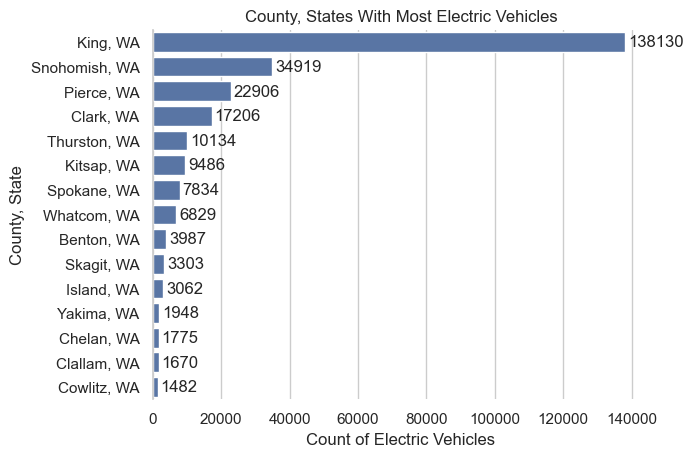

In [11]:
pop_county_states = duckdb.sql(f"""
                    SELECT County, State, COUNT(County) AS Count FROM df
                    WHERE State IN {state_list}
                    GROUP BY County, State
                    ORDER BY Count DESC
                    LIMIT 15
                    """).df()
county_list = pop_county_states['County'].to_list()
pop_county_states["County, State"] = pop_county_states["County"] + ", " + pop_county_states["State"]
show_plot(False, False, pop_county_states, 'Count', 'County, State', 'County, States With Most Electric Vehicles', x_axis='Count of Electric Vehicles', despine='bottom', plot_type='bar')

**Analysis**

This chart confirms our theory that the dataset would be skewed towards Washington, as this shows that all the counties that have the greatest conecentration of EVs in the United States is within Washington. This will allow us to extract several insights across counties and cities, as the data relevant to Washington state in this dataset is quite large. 

King, Washington seems to have the largest amount of EVs, almost 3x more than the second largest concentrated, which is Snohomish, WA. This insight suggests that EV demand is quite high in that part of Washington, which can encourage importing EVs from manufacturers to these counties.

To further understand consumer needs, we can investigate the distribution of Electric Vehicle Types across cities within these counties.

#### Which cities (of those counties) have the highest amount of EVs, split by PHEVs and BEVs? Which cities represent the strongest EV demand hotspots for dealership placement?

First, let's see the top ten counties and cities with the highest amount of EVs:

In [40]:
top_counties_cities = duckdb.sql(f"""
                            SELECT County, City, State, COUNT(*) AS Count from df
                            WHERE County IN {county_list}
                            GROUP BY County, City, State
                            ORDER BY Count DESC
                            LIMIT 10
                            """).df()
# Saving the county, city pairs since we don't want to have non-matching county/city pairs in the next step.
top_pairs = list(zip(top_counties_cities['County'], top_counties_cities['City']))
top_counties_cities

,County,City,State,Count
0,King,Seattle,WA,43250
1,King,Bellevue,WA,13683
2,Clark,Vancouver,WA,10395
3,King,Redmond,WA,9606
4,King,Kirkland,WA,7978
5,King,Sammamish,WA,7798
6,King,Renton,WA,7647
7,Snohomish,Bothell,WA,7273
8,Thurston,Olympia,WA,6508
9,Pierce,Tacoma,WA,6072


Since the state in the above table is always Washington, we can leave the State out in the following step.

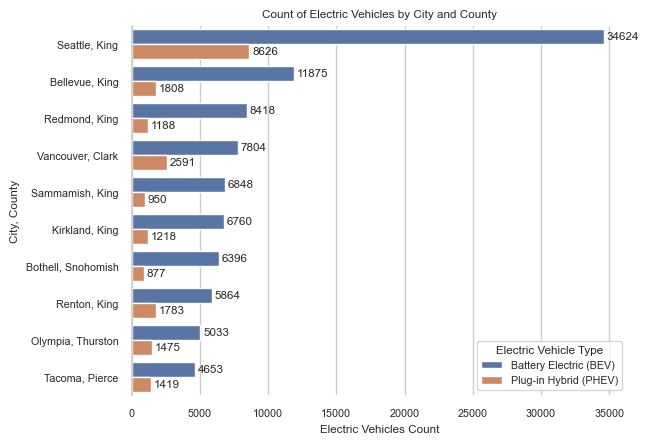

In [ ]:
# Now, we use IN with the counties we found in the first step like so: https://stackoverflow.com/a/29749286
top_evs_county_city = duckdb.sql(f"""
                            SELECT City, County, "Electric Vehicle Type", COUNT(*) AS Count from df
                            WHERE (County, City) IN {tuple(top_pairs)}
                            GROUP BY County, City, "Electric Vehicle Type"
                            ORDER BY Count DESC
                            """).df()
top_evs_county_city["City, County"] = top_evs_county_city["City"] + ", " + top_evs_county_city["County"] 
show_plot(False, True, top_evs_county_city, 'Count', 'City, County', 'Count of Electric Vehicles by City and County', x_axis = 'Electric Vehicles Count', hue = 'Electric Vehicle Type', despine='bottom', plot_type='bar')

**Analysis**

This shows the distribution of Electric Vehicles across the most popular cities, split by Electric Vehicle Type, ordered by the cities with the most vehicles to the least.

What's interesting is that of these ten cities, most are located in King County. All of the cities tend to have a strong preference of Battery Electric Vehicles. This indicates that Electric Vehicle dealerships should prioritize stocking Battery Electric Vehicles in showrooms, whereas manufacturers that are new to the EV market may have a higher change of selling Battery Electric Vehicles in these locations than Plug-In Hybrid Vehicles.

### Analyzing Brands & Models

#### What are the top ten most popular brands of Electric Vehicles?

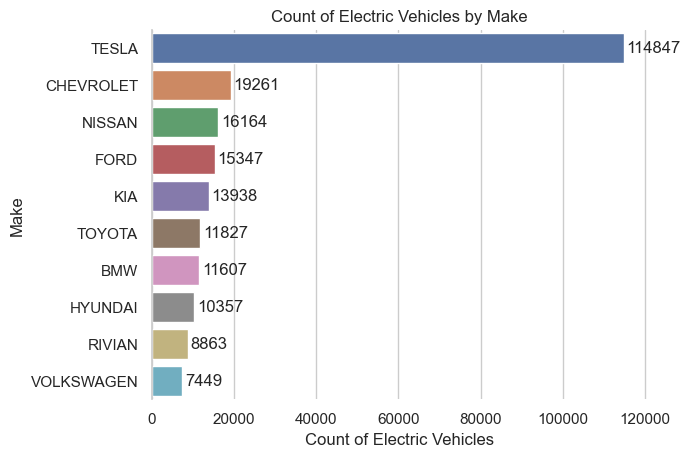

In [ ]:
top_10_makes = duckdb.sql("""
                            SELECT Make, COUNT(*) AS Count from df
                            GROUP BY Make
                            ORDER BY Count DESC
                            LIMIT 10
                            """).df()

top_makes = top_10_makes['Make'].tolist()
show_plot(True, False, top_10_makes, 'Count', 'Make', 'Count of Electric Vehicles by Make', x_axis='Count of Electric Vehicles', despine='bottom', hue='Make', plot_type='bar')

**Analysis**

This chart shows the most popular Electric Vehicle brands across the United States. This illustrates that Teslas seem to be the most popular EV brand by a very large margin. 

This provides some information on what the best selling EVs would be across the United States, and could provide some guidance on what brands Electric Vehicle manufacturers and dealerships should look into selling/manufacturing.

Given this, we can investigate which models are the most popular within the counties/cities that we found earlier. We can also analyze which brands besides Teslas would be most popular within the counties we found earlier.

#### Of those brands, which EV models should dealerships prioritize based on regional demand patterns?

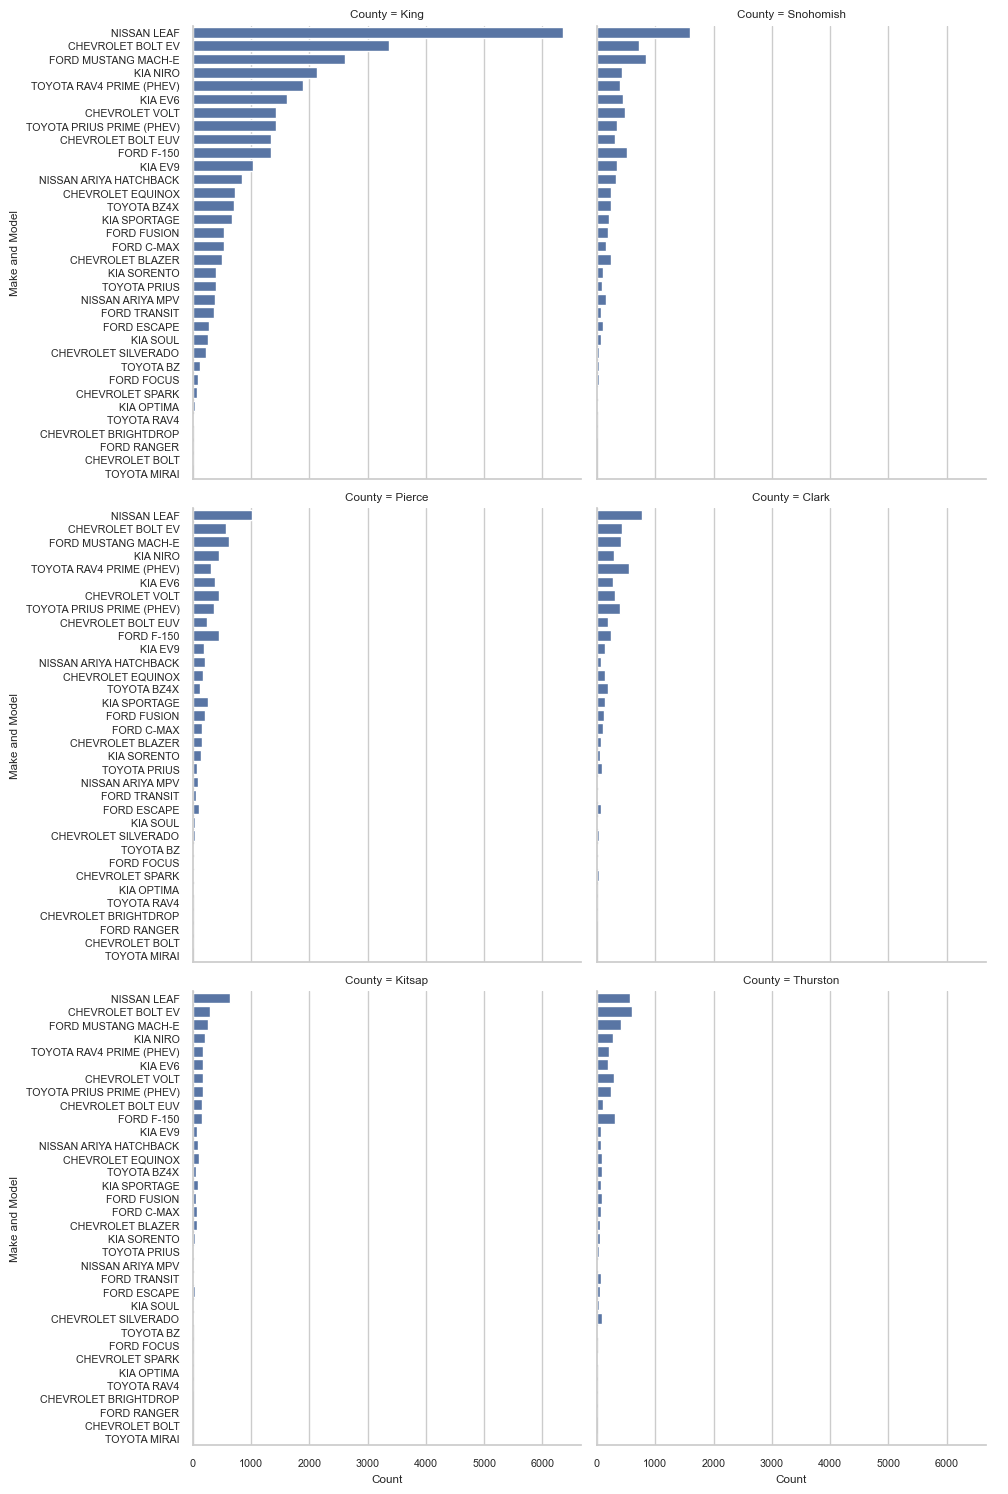

In [ ]:
pop_models = duckdb.sql(f"""
                            SELECT Make, Model, County, COUNT(*) AS Count from df
                            WHERE Make in {top_makes[:6]} AND Make <> 'TESLA' AND County IN {county_list[:6]}
                            GROUP BY Make, Model, County
                            ORDER BY Count DESC
                            """).df()
pop_models["Make and Model"] = pop_models["Make"] + " " + pop_models["Model"]
sns.catplot(pop_models, kind="bar", x="Count", y="Make and Model", col="County", col_wrap=2)

**Analysis**

This chart shows the five most popular makes and models within the top six counties. It provides some insight on the counts of each model and make within these counties.

Right off the bat, we can see that King County seems to have the most variety among EVs which indicates that the public more readily adopts EVs of various brands. This suggests that King County is one of the counties that would benefit from new dealerships, as there seems to be a lot of demand for EVs in this particular county compared to other counties. 

Dealerships and manufacturers could target King County for the most demand, or they could focus on the other counties where there are less EVs registered in total, but could present an untapped market. 

For analysis in the future, this dataset could also be combined with a company dataset to see the presence of companies in each county, as this may indicate the reason for high and widespread EV adoption in King County in particular.

#### How does the count of EVs model years change over time in the top 10 counties?

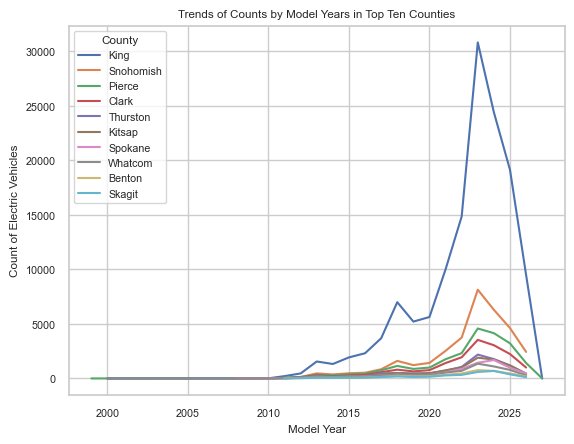

In [ ]:
top_10_counties = duckdb.sql("""
                            SELECT County, COUNT(*) AS Count from df
                            GROUP BY County
                            ORDER BY Count DESC
                            LIMIT 10
                            """).df()
county_list = top_10_counties['County'].tolist()

county_vs_year = duckdb.sql(f"""
                            SELECT County, "Model Year", COUNT(*) AS Count from df
                            WHERE County IN {county_list}
                            GROUP BY County, "Model Year"
                            ORDER BY Count DESC
                            """).df()
show_plot(True, True, county_vs_year, 'Model Year', 'Count', 'Trends of Counts by Model Years in Top Ten Counties', x_axis='Model Year', y_axis='Count of Electric Vehicles', hue='County', plot_type='line')

**Analysis**

This chart shows the popularity of certain model years of EVs within the top ten counties with the most EVs. 

Some interesting observations are that almost all of these counties seem to have a spike in EV models around 2017, and a huge spike around 2023. Perhaps these spike or changes in the amount of EV models could indicate that manufacturers were more readily making EVs for consumers, or that consumers were more readily purchasing EVs that were made during those model years. What's interesting is that those model years could still be increasing even now if consumers are buying old EV models due to their affordability in this economy.

Although there seems to be a steep decline in the number of recorded EVs in this dataset, amnufacturers and dealerships can examine this and consider that there may be a spike in EVs once more depending on various economic, and possibly, political factors. This indicates that there may be a potential uptick in EVs depending on variables like increasing gas prices, but could also fluctuate due to a lack of readily available energy supplies which are locally or globally sourced.

#### Which top five non-Tesla brands dominate EV demand in high-adoption regions in the top five counties we found earlier (in Washington State)? How should this influence dealerships and their strategy?

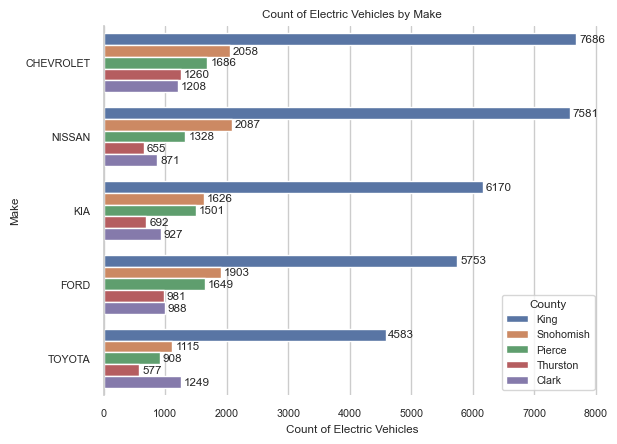

In [14]:
pop_non_tesla = duckdb.sql(f"""
                            SELECT Make, County, COUNT(*) AS Count from df
                            WHERE County IN {county_list[:5]} AND Make in {top_makes[:6]} AND Make <> 'TESLA'
                            GROUP BY Make, County
                            ORDER BY Count DESC
                            """).df()
show_plot(False, True, pop_non_tesla, 'Count', 'Make', 'Count of Electric Vehicles by Make', x_axis='Count of Electric Vehicles', despine='bottom', hue='County', plot_type='bar')

This bar plot represents the most popular brands within the top five counties with the most EVs. 

What's interesting is that King County seems to be leading in terms of their adoption of various brands. On the other hand, some places like Clark county tend to prefer Toyotas over other brands. 

This suggests that although King County tends to prefer Chevrolets, other counties may prefer a different brand such as Toyotas over Chevrolets. Dealerships and manufacturers can use this insight to their advantage, as certain counties prefer certain brands over others. As such, manufacturers and dealerships may need to carry out detailed research on the consumers within these counties, as which audience they are trying to target changes the brand and models of the cars they should import.

### Analyzing PHEV and BEV Split

#### How have the number of PHEVs and BEVs changed over the years?

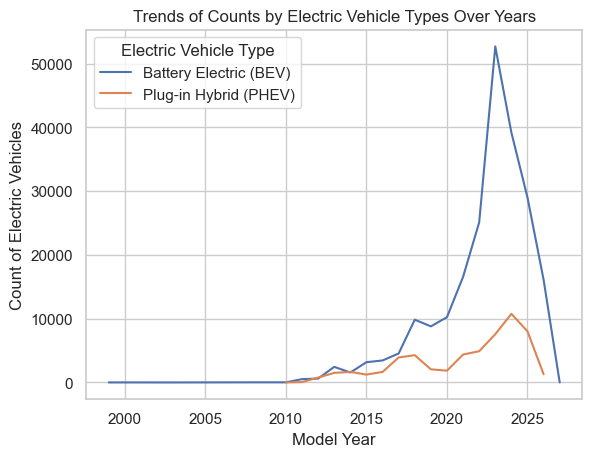

In [66]:
yearly_dist = duckdb.sql("""
                    SELECT "Electric Vehicle Type", "Model Year", COUNT("Model Year") AS Count FROM df
                    GROUP BY "Electric Vehicle Type", "Model Year"
                    ORDER BY Count DESC
                    """).df()
show_plot(True, False, yearly_dist, 'Model Year', 'Count', 'Trends of Counts by Electric Vehicle Types Over Years', x_axis='Model Year', y_axis='Count of Electric Vehicles', hue='Electric Vehicle Type', plot_type='line')

This chart shows the trends found when charting model years and counts of different Electric Vehicle Types such as Battery Electric and Plug-In Hybrid.

What's interesting is that this mirrors the other line chart that was shown earlier, which also had two spike around 2017, and 2024. This chart confirms our theory about the other line chart, which indicated that the EVs that are most registered in Washington tend to be manufactured in 2017 and 2024. Moreover, there seems to be another small spike in 2013, which makes me wonder if the spike in popular EV models is cyclical. Another thing I wonder if is Tesla tends to release a model every few years, which would explain why this spike is cyclical.

Dealerships and manufacturers could theoretically use this information on cyclical spikes to sell or release new models that don't align with the spikes to ensure that they are not overshadowed by other brands who release cars during the same year. Or if they'd prefer to follow market trends, they could release their cars a year before the spikes we see on the graph.

### Analyzing Electric Ranges

#### How does Minimum and Maximum Electric Ranges change for the top EV brands?

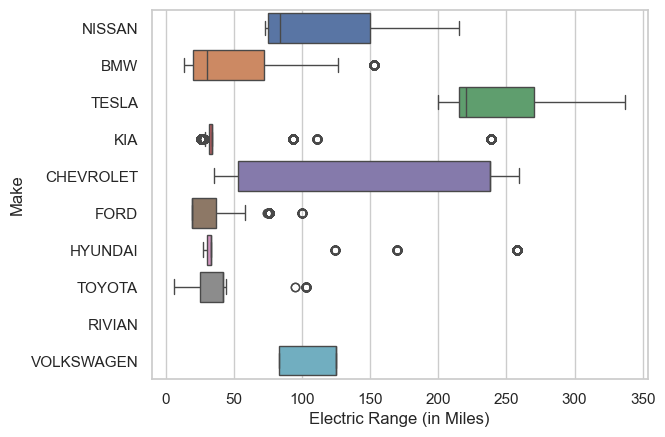

In [16]:
elec_boxplot = duckdb.sql(f"""
                    SELECT Make, "Electric Range (in Miles)" from df
                    WHERE Make IN {top_makes}
                    """).df()
sns.boxplot(elec_boxplot, x='Electric Range (in Miles)', y='Make', hue='Make')
plt.show()

This chart illsutrates the Electric Ranges across brands (since each brand can have multiple models that they sell). 

Chevrolet has the biggest range of Electric Ranges within the models that they sell. This could potentially explain why the second most preferred brand in King County (after Teslas) was Chevrolet, which overlaps with the electric range of Teslas. This boxplot also shows us that Teslas tend to be in the lead even within Electric Range, which might be why they are so popular compared to other brands, since they not only specialize in Electric Vehicles, but also tend to outdo their competitors when it comes to range capabilities.

This encourages dealers and manufacturers to research and incorporate methods to make their cars have a high electric range, as that may be the one reason why consumers tend to buy their brand more often. 

Although this might be the case, it's a bit intriguing that Toyota has a very small electric range compared to other brands as can be seen in this boxplot. Perhaps brands that do have smaller Electric Ranges like Toyota provide a competitive edge to consumers in other facets of the cars that they make, such as resale value etc. that could be confounding variables.

#### How has Electric Range changed across model years and Electric Vehicle Type, and what does this suggest about evolving consumer expectations?

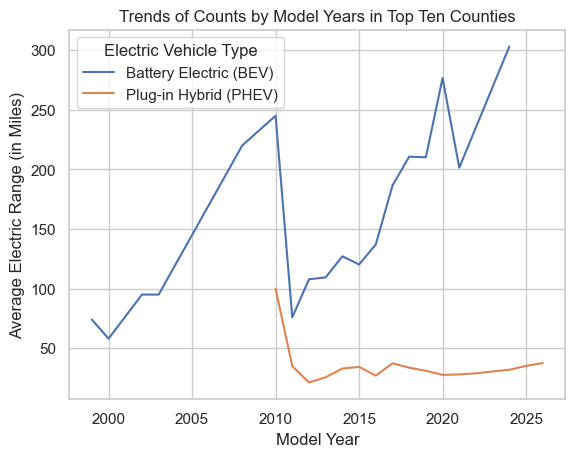

In [17]:
pop_city = duckdb.sql("""
                    SELECT "Model Year", "Electric Vehicle Type", AVG("Electric Range (in Miles)") AS Average from df_elec
                    GROUP BY "Model Year", "Electric Vehicle Type"
                    """).df()
show_plot(True, False, pop_city, 'Model Year', 'Average', 'Trends of Counts by Model Years in Top Ten Counties', y_axis='Average Electric Range (in Miles)', hue='Electric Vehicle Type', plot_type='line')

This chart shows how the Electric Ranges of EVs has changed over model years that were registered. It is also split by the EV type (Battery Electric or Hybrid Plugin).

An intriguing part of this chart is that Hybrid Plugin cars seem to plateau around 2012, and seem to be steady in terns of Electric Ranges. On the other hand, Battery Electric seems to have increasing Electric Range, and seems to be improving by leaps and bounds. 

This could be because consumers tend to prefer Battery Electric Vehicles. For dealerships and munfacturers, this could indicate that if they'd like to enter the market in Washington, they'd need to release cars that would need to compete with the rising Electric Ranges. 

This could be hard for new dealerships or manufacturers that are new entrants to the EV market, but this also calls into question whether the only important feature is the large Electric Range. But as we saw in the previous chart, some popular brands do not have large electric ranges, so perhaps they have other features that are attractive to consumers.

The fact that the electric ranges plateau for Plugin Hybrid vehicles could be a good thing for manufacturers and dealerships that are new entrants to the EV market, as this might mean consumers don't consider electric range as being the primary reason they purchase EVs but rather other features that may not be represented in this dataset.

## Key Insights

## Conclusions and Next Steps